In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import random
from PIL import Image

In [3]:
# =============================================================================
# CLASS: HOTSPOTTER MATCHER
# =============================================================================
class HotSpotterPOC:
    def __init__(self):
        # 1. Initialize SIFT Detector
        self.sift = cv2.SIFT_create()

        # 2. Initialize Matcher (FLANN-based is faster/standard for SIFT)
        FLANN_INDEX_KDTREE = 1
        index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
        search_params = dict(checks=50) # Higher checks = more precision, slower
        self.matcher = cv2.FlannBasedMatcher(index_params, search_params)

    def get_features(self, image):
        """
        Extracts Keypoints (locations) and Descriptors (vectors) from an image.
        """
        # SIFT works on grayscale
        if len(image.shape) == 3:
            gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        else:
            gray = image

        # Detect and Compute
        keypoints, descriptors = self.sift.detectAndCompute(gray, None)
        return keypoints, descriptors

    def match_images(self, img1, img2, ratio_thresh=0.75):
        """
        Performs the full HotSpotter pipeline:
        1. Extract Features
        2. Nearest Neighbor Match
        3. Ratio Test (Lowe's test)
        4. Spatial Verification (RANSAC)
        """
        # A. Extract Features
        kp1, des1 = self.get_features(img1)
        kp2, des2 = self.get_features(img2)

        # Check if features were found
        if des1 is None or des2 is None or len(des1) < 2 or len(des2) < 2:
            return 0, None, None

        # B. KNN Matching (k=2)
        # Find the top 2 best matches for every feature
        raw_matches = self.matcher.knnMatch(des1, des2, k=2)

        # C. Lowe's Ratio Test
        # If Match 1 is much better than Match 2, keep it. 
        # If they are similar, it's ambiguous (e.g. repeating patterns), discard.
        good_matches = []
        for m, n in raw_matches:
            if m.distance < ratio_thresh * n.distance:
                good_matches.append(m)

        # D. Spatial Verification (RANSAC)
        # We need at least 4 matches to calculate a Homography (geometric transformation)
        score = 0
        matches_mask = None
        final_matches = []

        if len(good_matches) > 4:
            # Extract coordinates of the matching points
            src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
            dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

            # Find Homography with RANSAC
            # This checks: "Is there a rotation/scale/warp that aligns these points?"
            M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
            
            if mask is not None:
                matches_mask = mask.ravel().tolist()
                
                # Count "Inliers" (Points that fit the geometry)
                # This is our "HotSpotter Score"
                score = np.sum(matches_mask)
                
                # Filter out the outliers for visualization
                final_matches = [good_matches[i] for i in range(len(good_matches)) if matches_mask[i]]
        else:
            # Not enough matches to verify geometry
            score = 0
            matches_mask = None

        return score, (kp1, kp2), final_matches

    def visualize_match(self, img1, img2, keypoints, matches, score):
        """
        Draws lines connecting the spatially verified spots.
        """
        kp1, kp2 = keypoints
        
        # cv2.drawMatches creates a new image with img1 and img2 side-by-side
        # and draws lines between the matching keypoints.
        result_img = cv2.drawMatches(
            img1, kp1, 
            img2, kp2, 
            matches, None, 
            flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
            matchColor=(0, 255, 0) # Green lines for verified matches
        )

        plt.figure(figsize=(15, 7))
        plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
        plt.title(f"HotSpotter Result | Verified Inliers: {score}", fontsize=16)
        plt.axis('off')
        plt.show()

In [4]:
# =============================================================================
# MAIN EXECUTION (DEMO)
# =============================================================================
def main():
    # 1. Setup
    DATA_DIR = "/home/Joshua/Downloads/leopard_toad_identification/dataset/dataset_reid_crops"
    
    # Get all images
    all_images = [f for f in os.listdir(DATA_DIR) if f.endswith('.jpg')]
    if len(all_images) < 2:
        print("Need at least 2 images in dataset_reid_crops")
        return

    # 2. Simulate a "Positive Pair" (Same Toad, Rotated)
    filename = all_images[0]
    img_path = os.path.join(DATA_DIR, filename)
    
    # Load Image A
    img_a = cv2.imread(img_path)
    
    # Create Image B (Synthetic "Camera 2" View)
    # Rotate 45 degrees and dim the brightness
    rows, cols = img_a.shape[:2]
    M = cv2.getRotationMatrix2D((cols/2, rows/2), 45, 1) # 45 degree rotation
    img_b = cv2.warpAffine(img_a, M, (cols, rows))
    img_b = (img_b * 0.7).astype(np.uint8) # Dim brightness

    # Load Image C (Different Toad)
    filename_c = all_images[1]
    img_c = cv2.imread(os.path.join(DATA_DIR, filename_c))

    # 3. Initialize HotSpotter
    hotspotter = HotSpotterPOC()

    print("--- Running HotSpotter POC ---")

    # TEST 1: Same Toad (Rotated)
    print(f"\nComparing: {filename} vs. Self (Rotated 45°)")
    score, kps, matches = hotspotter.match_images(img_a, img_b)
    print(f"HotSpotter Score (Inliers): {score}")
    
    if score > 10: # Threshold for a "Good Match" in HotSpotter is usually > 6-10
        print("MATCH CONFIRMED (Geometric Verification Passed)")
        hotspotter.visualize_match(img_a, img_b, kps, matches, score)
    else:
        print("MATCH FAILED")

    # TEST 2: Different Toads
    print(f"\nComparing: {filename} vs. {filename_c} (Different Individual)")
    score_diff, kps_diff, matches_diff = hotspotter.match_images(img_a, img_c)
    print(f"HotSpotter Score (Inliers): {score_diff}")

    if score_diff < 5:
        print("CORRECTLY REJECTED (Low Inlier Count)")
    else:
        print("FALSE POSITIVE (This shouldn't happen often)")
        hotspotter.visualize_match(img_a, img_c, kps_diff, matches_diff, score_diff)

--- Running HotSpotter POC ---

Comparing: 785c018c-image_359_crop0.jpg vs. Self (Rotated 45°)
HotSpotter Score (Inliers): 1641
MATCH CONFIRMED (Geometric Verification Passed)


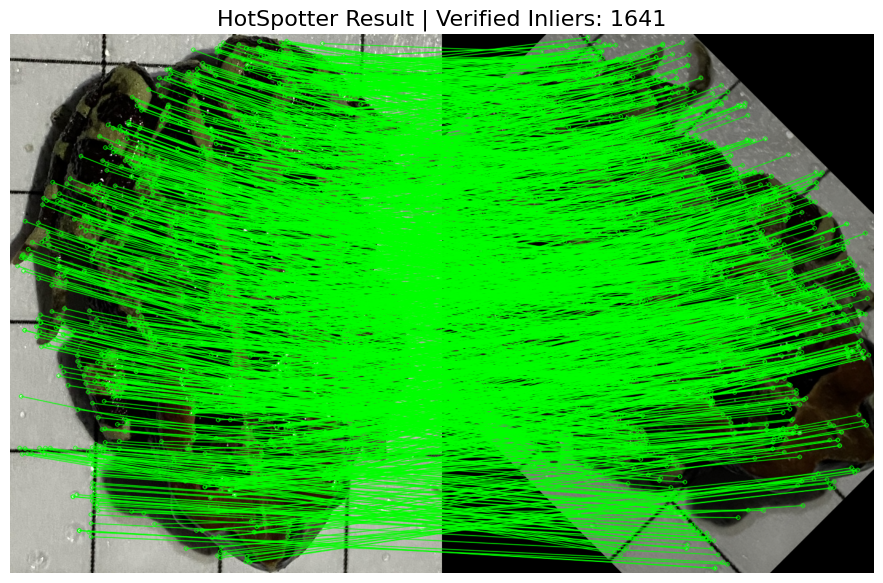


Comparing: 785c018c-image_359_crop0.jpg vs. 7845412c-image_114_crop0.jpg (Different Individual)
HotSpotter Score (Inliers): 5
FALSE POSITIVE (This shouldn't happen often)


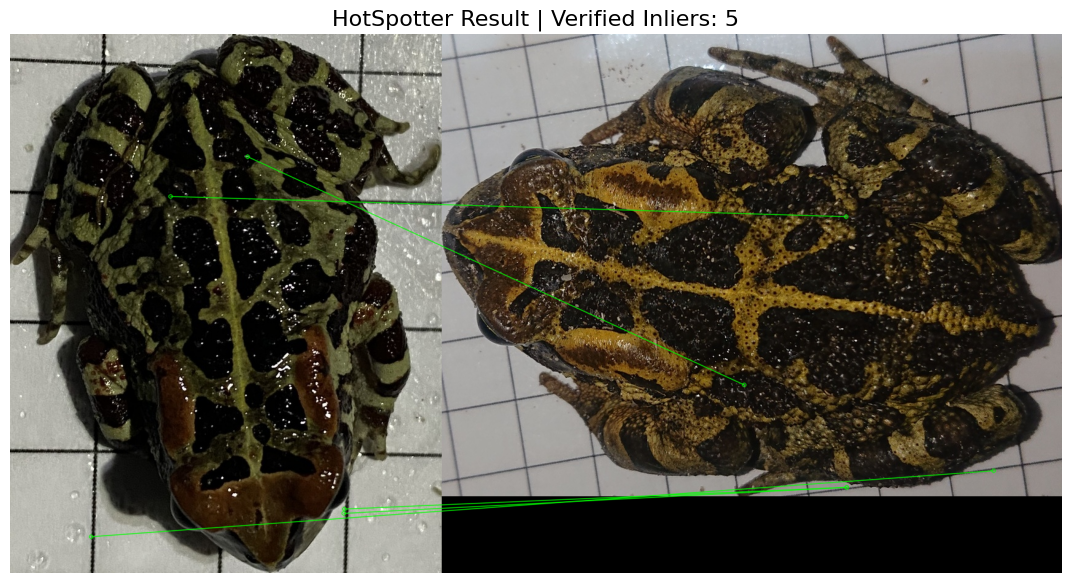

In [ ]:
main()